# DLAV Project - Phase 1

In this notebook we will train a very simple planner on data coming from a driving simulator. You are given a dash cam image of the current state of the driving vehicle, and the past positions of this vehicle, and you are asked to plan its future route.

This notebook will take you through steps on building this planner to solve the task. The full skeleton of the code together with some very simple implementations of each module are provided for your comfort. So all the cells below will run without you needing to change anything, but the performance won't be very good. You are asked to re-implement and play with most of the modules yourself to be able to have better performance.

P.S. to enable fast compute, you should use GPUs in google colab. The code works without GPUs, but it'll be much faster to use GPUs, specially if your model gets bigger and bigger! You can utilize Colab's GPUs by selecting "Change runtime type" in the Runtime menu on top of this page. There you can select "T4 GPU". This would restart your runtime, so you'll need to re-run everything from the top.

The first step is to prepare the data. The code below will download the data from google drive and extract it here for your code to use. Whenever your session gets restarted, remember to re-run this cell to re-download the data.

In [1]:
# Install gdown to handle Google Drive file download
!pip install -q gdown

import gdown
import zipfile

download_url = f"https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr"
output_zip = "dlav_train.zip"
gdown.download(download_url, output_zip, quiet=False)  # Downloads the file to your drive
with zipfile.ZipFile(output_zip, 'r') as zip_ref:  # Extracts the downloaded zip file
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu"
output_zip = "dlav_val.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV"
output_zip = "dlav_test_public.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

Downloading...
From (original): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr
From (redirected): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr&confirm=t&uuid=ee2a5171-c6ee-496a-8dca-8f2255609dad
To: /content/dlav_train.zip
100%|██████████| 439M/439M [00:03<00:00, 113MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu
From (redirected): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu&confirm=t&uuid=495c9d34-099f-4f8d-acf8-0fa3135815a1
To: /content/dlav_val.zip
100%|██████████| 87.8M/87.8M [00:00<00:00, 119MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV
From (redirected): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV&confirm=t&uuid=a0a8a7e3-9001-46fe-bab4-e4e1037b60c8
To: /content/dlav_test_public.zip
100%|██████████| 86.6M/86.6M [00:00<00:00, 139MB/s]


Now lets load the data and visualize the first few examples to see what we are dealing with!

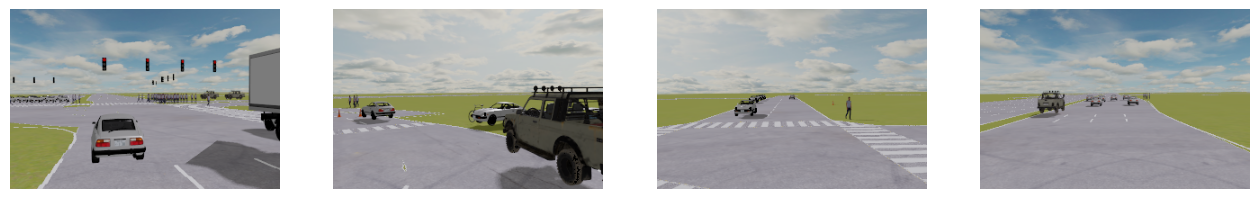

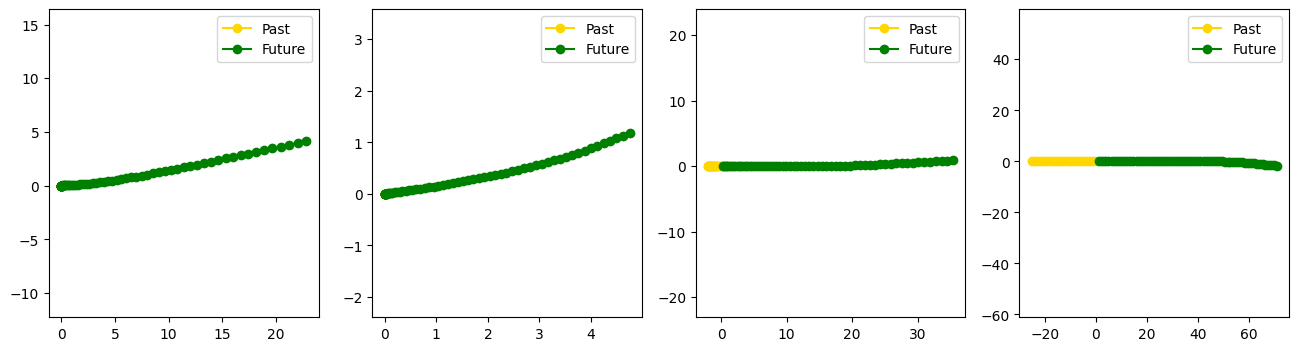

In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random

k = 4
# load the data
data = []
for i in random.choices(np.arange(1000), k=k):
    with open(f"train/{i}.pkl", "rb") as f:
        data.append(pickle.load(f))

# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].imshow(data[i]["camera"])
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].plot(data[i]["sdc_history_feature"][:, 0], data[i]["sdc_history_feature"][:, 1], "o-", color="gold", label="Past")
    axis[i].plot(data[i]["sdc_future_feature"][:, 0], data[i]["sdc_future_feature"][:, 1], "o-", color="green", label="Future")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now its time to make our hands dirty!

In the following cells we will define the classes we need to do a proper training in pytorch.

1. We will start with defining a Dataset class which loads the data and does some basic preprocessing. You can further process this data as you see fit.
2. We then define the logger which receives training metrics and logs and prints/visualizes them. Having a good logger means a lot when dealing with neural network training! The logger implemented here is very simple and we strongly suggest you try other ways of visualizing your losses and metrics. Be creative ;)
3. We then proceed with defining the core part of the pipeline, the model. You are going to mainly implement the model yourself, but we have provided a very simple model so that the code runs as is so that you can see how the whole framework runs all in all.
4. Finally, we define the training funciton which contains the training loop, and we call it to see the magic! You'll need to also do a lot of changes here, from the batch size and learning rate, to adding augmentation schemes and schedulers, etc.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import pickle
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models

class DrivingDataset(Dataset):
    def __init__(self, file_list, test=False, augment=True):
        self.samples = file_list
        self.test = test
        self.augment = augment and (not test)
        self.command_map = {'forward': 0, 'left': 1, 'right': 2}

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
        self.color_jitter = transforms.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
        )

        # Milestone 2 semantic labels: 0..14 in README.
        self.num_semantic_classes = 15
        self.max_depth = 100.0  # used only for robust normalization/clipping

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        with open(self.samples[idx], 'rb') as f:
            data = pickle.load(f)

        # Camera image: HWC uint8 -> normalized CHW float.
        camera = torch.FloatTensor(data['camera']).permute(2, 0, 1) / 255.0
        if self.augment:
            camera = self.color_jitter(camera)
        camera = self.normalize(camera)

        # Motion history: relative xy + sin/cos heading.
        history_raw = torch.FloatTensor(data['sdc_history_feature'])  # (21, 3)
        last_pos = history_raw[-1, :2].clone()
        history_xy = history_raw[:, :2] - last_pos
        heading = history_raw[:, 2:3]
        history = torch.cat([history_xy, torch.sin(heading), torch.cos(heading)], dim=-1)
        if self.augment:
            history[:, :2] += torch.randn_like(history[:, :2]) * 0.03

        command = torch.tensor(self.command_map[data['driving_command']], dtype=torch.long)

        result = {
            'camera': camera,
            'history': history,
            'command': command,
            'last_pos': last_pos,
        }

        if not self.test:
            future_raw = torch.FloatTensor(data['sdc_future_feature'])
            future_xy = future_raw[:, :2] - last_pos
            future_h = future_raw[:, 2:3]
            result['future'] = torch.cat([future_xy, torch.sin(future_h), torch.cos(future_h)], dim=-1)

            # Auxiliary labels for Milestone 2.
            if 'semantic_label' in data:
                result['semantic'] = torch.LongTensor(data['semantic_label'])  # (H, W)

            if 'depth' in data:
                depth = torch.FloatTensor(data['depth'])  # (H, W, 1) or (H, W)
                if depth.ndim == 3:
                    depth = depth.permute(2, 0, 1)        # (1, H, W)
                else:
                    depth = depth.unsqueeze(0)
                # Log-normalized depth is much easier to regress than raw depth.
                depth = torch.clamp(depth, min=0.0, max=self.max_depth)
                depth = torch.log1p(depth) / torch.log1p(torch.tensor(self.max_depth))
                result['depth'] = depth.float()

        return result


In [44]:
from torch.utils.tensorboard import SummaryWriter

def cumsum_trajectory(pred_deltas):
    """
    Convert per-step deltas to cumulative positions.
    pred_deltas : (B, 60, 4)  — dx, dy, sin_dh, cos_dh
    returns     : (B, 60, 4)
    """
    xy  = torch.cumsum(pred_deltas[..., :2], dim=1)
    ang = pred_deltas[..., 2:]                       # keep sin/cos as-is
    return torch.cat([xy, ang], dim=-1)


def compute_ade(pred_xy, gt_xy):
    """
    pred_xy, gt_xy : (B, 60, 2)  — relative coordinates
    """
    return torch.norm(pred_xy - gt_xy, p=2, dim=-1).mean()


def compute_fde(pred_xy, gt_xy):
    """
    pred_xy, gt_xy : (B, 60, 2)
    """
    return torch.norm(pred_xy[:, -1] - gt_xy[:, -1], p=2, dim=-1).mean()

class Logger:
    def __init__(self, log_dir="./runs/experiment"):
        self.writer = SummaryWriter(log_dir)
        print(f"TensorBoard logs → {log_dir}")

    def log(self, step=None, **metrics):
        parts = [f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}"
                 for k, v in metrics.items()]
        prefix = f"[Step {step}] " if step is not None else ""
        print(prefix + " | ".join(parts))
        if step is not None:
            for k, v in metrics.items():
                self.writer.add_scalar(k, v, step)

    def close(self):
        self.writer.close()

In [43]:
class PerceptionAwarePlanner(nn.Module):
    """
    Milestone 2 planner with auxiliary perception supervision.

    Shared encoder:
      ResNet-34 convolutional trunk -> visual feature map.

    Planning branch:
      global pooled visual feature + GRU(history) + command embedding -> autoregressive GRU decoder.

    Auxiliary branches:
      semantic segmentation head and depth estimation head from the shared visual feature map.
      These heads are used during training only; inference still outputs trajectory from allowed test inputs.
    """

    def __init__(self, num_semantic_classes=15, horizon=60):
        super().__init__()
        self.horizon = horizon
        self.num_semantic_classes = num_semantic_classes

        # Torchvision compatibility: new versions use weights=..., old versions use pretrained=True.
        try:
            backbone = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        except Exception:
            backbone = models.resnet34(pretrained=True)

        self.stem = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4
        )
        self.vision_dim = 512
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.history_dim = 128
        self.history_encoder = nn.GRU(
            input_size=4,
            hidden_size=self.history_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.1
        )

        self.command_dim = 64
        self.command_embedding = nn.Embedding(3, self.command_dim)
        self.film_scale = nn.Linear(self.command_dim, self.vision_dim)
        self.film_bias = nn.Linear(self.command_dim, self.vision_dim)

        fusion_in = self.vision_dim + self.history_dim + self.command_dim
        self.context_mlp = nn.Sequential(
            nn.Linear(fusion_in, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
        )

        self.decoder_cell = nn.GRUCell(input_size=4, hidden_size=256)
        self.output_head = nn.Linear(256, 4)

        # Lightweight auxiliary decoder. Output is interpolated to image size in forward().
        self.aux_decoder = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        self.semantic_head = nn.Conv2d(128, num_semantic_classes, kernel_size=1)
        self.depth_head = nn.Conv2d(128, 1, kernel_size=1)

    def forward(self, camera, history, command, return_aux=True):
        B, _, H, W = camera.shape

        fmap = self.stem(camera)                         # (B, 512, h, w)
        vis = self.global_pool(fmap).flatten(1)          # (B, 512)

        cmd = self.command_embedding(command)            # (B, 64)
        scale = torch.sigmoid(self.film_scale(cmd))
        bias = self.film_bias(cmd)
        vis = vis * scale + bias

        _, h_n = self.history_encoder(history)
        hist = h_n[-1]

        ctx = self.context_mlp(torch.cat([vis, hist, cmd], dim=1))

        waypoints = []
        h_dec = ctx
        step_input = torch.zeros(B, 4, device=camera.device)
        for _ in range(self.horizon):
            h_dec = self.decoder_cell(step_input, h_dec)
            delta = self.output_head(h_dec)
            waypoints.append(delta)
            step_input = delta
        plan_delta = torch.stack(waypoints, dim=1)       # (B, 60, 4)

        out = {'plan': plan_delta}

        if return_aux:
            aux = self.aux_decoder(fmap)
            semantic_logits = self.semantic_head(aux)
            depth_pred = self.depth_head(aux)
            semantic_logits = F.interpolate(semantic_logits, size=(H, W), mode='bilinear', align_corners=False)
            depth_pred = F.interpolate(depth_pred, size=(H, W), mode='bilinear', align_corners=False)
            out['semantic_logits'] = semantic_logits
            out['depth'] = depth_pred

        return out

# Keep the old variable name usable in later cells.
DrivingPlanner = PerceptionAwarePlanner


In [46]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


def train(model, train_loader, val_loader, optimizer, logger,
          num_epochs=50, scheduler=None,
          lambda_sem=0.20, lambda_depth=0.10, lambda_ang=0.05, lambda_fde=0.20):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    print(f"Training on: {device}")

    reg_loss = nn.SmoothL1Loss(beta=1.0)
    ce_loss = nn.CrossEntropyLoss(ignore_index=255)

    # Later waypoints matter more for ADE/FDE stability.
    t_weights = torch.linspace(1.0, 2.0, 60, device=device).view(1, 60, 1)
    t_weights = t_weights / t_weights.mean()

    best_ade = float('inf')

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for idx, batch in enumerate(train_loader):
            camera = batch['camera'].to(device)
            history = batch['history'].to(device)
            command = batch['command'].to(device)
            future = batch['future'].to(device)

            optimizer.zero_grad(set_to_none=True)

            outputs = model(camera, history, command, return_aux=True)
            pred_traj = cumsum_trajectory(outputs['plan'])

            loss_xy = F.smooth_l1_loss(pred_traj[..., :2], future[..., :2], reduction='none', beta=1.0)
            loss_xy = (loss_xy * t_weights).mean()
            loss_ang = reg_loss(pred_traj[..., 2:], future[..., 2:])
            loss_fde = compute_fde(pred_traj[..., :2], future[..., :2])

            loss = loss_xy + lambda_ang * loss_ang + lambda_fde * loss_fde

            if 'semantic' in batch:
                semantic = batch['semantic'].to(device)
                loss_sem = ce_loss(outputs['semantic_logits'], semantic)
                loss = loss + lambda_sem * loss_sem
            else:
                loss_sem = torch.tensor(0.0, device=device)

            if 'depth' in batch:
                depth = batch['depth'].to(device)
                loss_depth = reg_loss(outputs['depth'], depth)
                loss = loss + lambda_depth * loss_depth
            else:
                loss_depth = torch.tensor(0.0, device=device)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            train_loss += loss.item()

            if idx % 10 == 0:
                logger.log(
                    step=epoch * len(train_loader) + idx,
                    train_loss=float(loss.item()),
                    loss_xy=float(loss_xy.item()),
                    loss_sem=float(loss_sem.item()),
                    loss_depth=float(loss_depth.item())
                )

        model.eval()
        val_loss_sum = 0.0
        ade_list, fde_list = [], []

        with torch.no_grad():
            for batch in val_loader:
                camera = batch['camera'].to(device)
                history = batch['history'].to(device)
                command = batch['command'].to(device)
                future = batch['future'].to(device)

                outputs = model(camera, history, command, return_aux=False)
                pred_traj = cumsum_trajectory(outputs['plan'])

                val_loss = reg_loss(pred_traj[..., :2], future[..., :2])
                val_loss_sum += val_loss.item()
                ade_list.append(compute_ade(pred_traj[..., :2], future[..., :2]).item())
                fde_list.append(compute_fde(pred_traj[..., :2], future[..., :2]).item())

        epoch_train_loss = train_loss / len(train_loader)
        epoch_val_loss = val_loss_sum / len(val_loader)
        epoch_ade = float(np.mean(ade_list))
        epoch_fde = float(np.mean(fde_list))

        print(
            f"Epoch {epoch+1:3d}/{num_epochs} | "
            f"Train {epoch_train_loss:.4f} | Val {epoch_val_loss:.4f} | "
            f"ADE {epoch_ade:.4f} | FDE {epoch_fde:.4f}"
        )

        logger.log(
            step=(epoch + 1) * len(train_loader),
            val_loss=epoch_val_loss,
            val_ade=epoch_ade,
            val_fde=epoch_fde
        )

        if epoch_ade < best_ade:
            best_ade = epoch_ade
            torch.save(model.state_dict(), "best_model_phase2_aux.pth")
            print(f"  ↳ New best ADE: {best_ade:.4f} — checkpoint saved.")

        if scheduler is not None:
            scheduler.step()

    print(f"\nTraining complete. Best ADE: {best_ade:.4f}")


def predict(model, test_loader, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in test_loader:
            camera = batch['camera'].to(device)
            history = batch['history'].to(device)
            command = batch['command'].to(device)
            last_pos = batch['last_pos'].to(device)

            outputs = model(camera, history, command, return_aux=False)
            pred_traj = cumsum_trajectory(outputs['plan'])
            pred_xy_abs = pred_traj[..., :2] + last_pos.unsqueeze(1)
            all_preds.append(pred_xy_abs.cpu().numpy())

    return np.concatenate(all_preds, axis=0)


In [47]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import os

train_data_dir = "train"
val_data_dir = "val"

train_files = sorted([
    os.path.join(train_data_dir, f)
    for f in os.listdir(train_data_dir) if f.endswith('.pkl')
], key=lambda p: int(os.path.splitext(os.path.basename(p))[0]))
val_files = sorted([
    os.path.join(val_data_dir, f)
    for f in os.listdir(val_data_dir) if f.endswith('.pkl')
], key=lambda p: int(os.path.splitext(os.path.basename(p))[0]))

train_dataset = DrivingDataset(train_files, test=False, augment=True)
val_dataset = DrivingDataset(val_files, test=False, augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True,
    num_workers=4, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=64, shuffle=False,
    num_workers=4, pin_memory=True
)

model = PerceptionAwarePlanner(num_semantic_classes=15)

# Differential learning rates: trunk small LR, new heads/planner larger LR.
trunk_params = list(model.stem.parameters())
new_params = [p for n, p in model.named_parameters() if not n.startswith('stem.')]

optimizer = optim.AdamW([
    {'params': trunk_params, 'lr': 3e-5},
    {'params': new_params, 'lr': 8e-4},
], weight_decay=1e-4)

num_epochs = 70
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
logger = Logger(log_dir="./runs/milestone2_aux")

print("Starting Milestone 2 auxiliary-task training...")
train(model, train_loader, val_loader, optimizer, logger,
      num_epochs=num_epochs, scheduler=scheduler,
      lambda_sem=0.20, lambda_depth=0.10, lambda_ang=0.05, lambda_fde=0.20)

logger.close()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


TensorBoard logs → ./runs/milestone1_improved
Starting training...
Training on: cuda


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Step 0] train_loss: 8.7604
[Step 10] train_loss: 4.9115
[Step 20] train_loss: 3.5003
[Step 30] train_loss: 3.0550
[Step 40] train_loss: 4.0999
[Step 50] train_loss: 3.0981
[Step 60] train_loss: 2.3406
[Step 70] train_loss: 1.5396
Epoch   1/50 | Train 3.3623 | Val 2.3739 | ADE 4.7867 | FDE 12.1913
[Step 79] val_loss: 2.3739 | val_ade: 4.7867 | val_fde: 12.1913
  ↳ New best ADE: 4.7867 — checkpoint saved.
[Step 79] train_loss: 2.0392
[Step 89] train_loss: 1.5684
[Step 99] train_loss: 1.4500
[Step 109] train_loss: 1.4055
[Step 119] train_loss: 1.1709
[Step 129] train_loss: 1.3946
[Step 139] train_loss: 1.9011
[Step 149] train_loss: 1.3174
Epoch   2/50 | Train 1.6060 | Val 1.4993 | ADE 3.1511 | FDE 8.0675
[Step 158] val_loss: 1.4993 | val_ade: 3.1511 | val_fde: 8.0675
  ↳ New best ADE: 3.1511 — checkpoint saved.
[Step 158] train_loss: 1.2959
[Step 168] train_loss: 1.2264
[Step 178] train_loss: 1.9209
[Step 188] train_loss: 2.6254
[Step 198] train_loss: 1.3625
[Step 208] train_loss: 1.3760

By running the code above, you have trained your first model!

In the saved run above, the training loss keeps decreasing while the validation ADE/FDE improves more slowly and sometimes fluctuates. That gap is a standard sign of **overfitting**: the model keeps fitting the training set better than it generalizes to validation data.

This model is still a reasonable Milestone 1 baseline, but the logs suggest that regularization, stronger augmentation, or better early stopping / checkpoint selection are important for stable generalization.

This model is very simple and does not necessarilly yield the optimal performance. You are asked to implement your own neural network architecture. You can use convolution networks, vision transformers, etc. Try with different architectures, different model sizes, and other hyper parameters such as learning rate and batch size to find the best performance. Other ideas could be to use augmentation thechniques to boost the performance, adding learning rate schedulers, and exploring other loss functions.

Once you are happy with your model, continue with the rest of the notebook to save your checkpoint and also visualize some plans coming from the model. The last cell will provide a `submission_phase1.csv` which you can submit to the leaderboard to see your results on the testing set.

In [48]:
torch.save(model.state_dict(), "phase2_aux_last.pth")


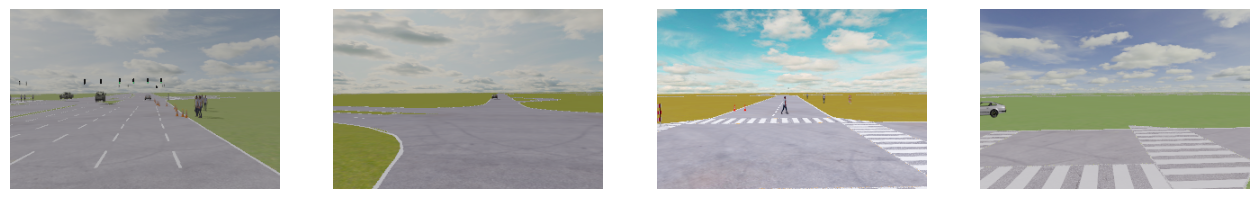

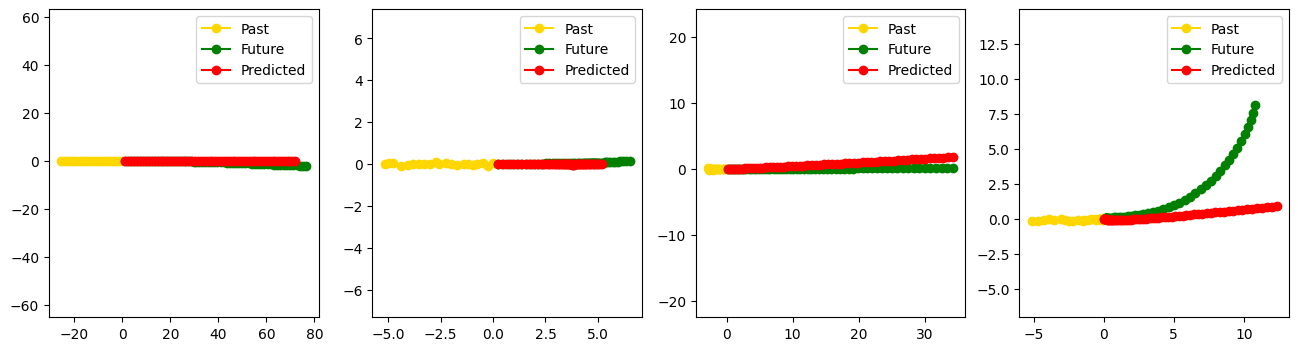

In [50]:
val_batch_zero = next(iter(val_loader))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

camera = val_batch_zero['camera'].to(device)
history = val_batch_zero['history'].to(device)
command = val_batch_zero['command'].to(device)
future = val_batch_zero['future'].to(device)
last_pos = val_batch_zero['last_pos'].to(device)

model.eval()
with torch.no_grad():
    outputs = model(camera, history, command, return_aux=True)
    pred_future = cumsum_trajectory(outputs['plan'])

last_pos_np = last_pos.cpu().numpy()
history_np = history.cpu().numpy()
future_np = future.cpu().numpy()
pred_np = pred_future.cpu().numpy()
camera_np = camera.cpu().numpy()

history_xy = history_np[:, :, :2] + last_pos_np[:, None, :]
future_xy = future_np[:, :, :2] + last_pos_np[:, None, :]
pred_xy = pred_np[:, :, :2] + last_pos_np[:, None, :]

k = 4
selected_indices = random.choices(np.arange(len(camera_np)), k=k)

fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i, idx in enumerate(selected_indices):
    img = camera_np[idx].transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    axis[i].imshow(img)
    axis[i].axis("off")
plt.show()

fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i, idx in enumerate(selected_indices):
    axis[i].plot(history_xy[idx, :, 0], history_xy[idx, :, 1], "o-", color="gold", label="Past")
    axis[i].plot(future_xy[idx, :, 0], future_xy[idx, :, 1], "o-", color="green", label="Future")
    axis[i].plot(pred_xy[idx, :, 0], pred_xy[idx, :, 1], "o-", color="red", label="Predicted")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

# Optional qualitative check for auxiliary heads.
if 'semantic_logits' in outputs:
    sem_pred = outputs['semantic_logits'].argmax(dim=1).cpu().numpy()
    depth_pred = outputs['depth'].squeeze(1).cpu().numpy()
    fig, axis = plt.subplots(2, k, figsize=(4*k, 8))
    for i, idx in enumerate(selected_indices):
        axis[0, i].imshow(sem_pred[idx], vmin=0, vmax=14)
        axis[0, i].set_title("Pred semantic")
        axis[0, i].axis("off")
        axis[1, i].imshow(depth_pred[idx])
        axis[1, i].set_title("Pred depth normalized")
        axis[1, i].axis("off")
    plt.show()


Now we run our model on the test set once, to get the plan of our model and save it for submission. Notice that the ground truth plans are removed for the test set, so you can not calculate the ADE metric on the test set yourself, and need to submit it to the leader board. By running the last cell, you'll be able to see a csv file called `submission_phase1.csv` by clicking on the folder icon on the left. Download it and submit it to the leaderboard to get your score.

In [51]:
with open(f"test_public/0.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())
# Note the absence of sdc_future_feature

dict_keys(['camera', 'depth', 'driving_command', 'sdc_history_feature', 'semantic_label'])


In [53]:
import pandas as pd

test_data_dir = "test_public"   # change to phase2 test directory name if different

test_files = [os.path.join(test_data_dir, fn) for fn in sorted(
    [f for f in os.listdir(test_data_dir) if f.endswith(".pkl")],
    key=lambda fn: int(os.path.splitext(fn)[0])
)]

test_dataset = DrivingDataset(test_files, test=True, augment=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PerceptionAwarePlanner(num_semantic_classes=15).to(device)
model.load_state_dict(torch.load("best_model_phase2_aux.pth", map_location=device))
model.eval()

all_plans = predict(model, test_loader, device=device)  # (N, 60, 2), absolute xy

total_samples, T, D = all_plans.shape
pred_xy_flat = all_plans.reshape(total_samples, T * D)

ids = np.arange(total_samples)
df_xy = pd.DataFrame(pred_xy_flat)
df_xy.insert(0, "id", ids)

new_col_names = ["id"]
for t in range(1, T + 1):
    new_col_names += [f"x_{t}", f"y_{t}"]
df_xy.columns = new_col_names

df_xy.to_csv("submission_phase2_aux.csv", index=False)
print(f"Shape of df_xy: {df_xy.shape}")


Shape of df_xy: (1000, 121)
